In [1]:
import os
import time
from functools import partial
from typing import Callable, Sequence

import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import scipy.io
from flax import serialization
from soap_jax import soap


from Utilities_pinn_euler1d import *

In [2]:
# 1. Load Sod shock-tube data
path = "SodShocktube_data.mat"
#path = "LaxShocktube_data.mat"
data = scipy.io.loadmat(path)

sss = 8
Rho0 = jnp.asarray(data["Rho"])[:, ::sss]
U0 = jnp.asarray(data["U"])[:, ::sss]
P0 = jnp.asarray(data["P"])[:, ::sss]
X0 = jnp.asarray(data["X"])[:, ::sss]
T0 = jnp.asarray(data["T"])[:, ::sss]

Nt_test, Nx_test = Rho0.shape
xl = float(X0[0, 0])
xr = float(X0[0, -1])
t0 = float(T0[0, 0])
tend = float(T0[-1, 0])

x_jump = 0.5 * (xl + xr)
ic_params = (float(Rho0[0, 0]), float(U0[0, 0]), float(P0[0, 0]), float(Rho0[0, -1]), float(U0[0, -1]), float(P0[0, -1]))
left_state = ic_params[:3]
right_state = ic_params[3:]

trange = (t0, tend)
xrange = (xl, xr)

T_grid = T0
X_grid = X0

t_test = T0.reshape(-1)
x_test = X0.reshape(-1)
test_inputs = create_test_inputs(t_test, x_test)
test_labels = jnp.stack([Rho0.reshape(-1), U0.reshape(-1),P0.reshape(-1)], axis=-1)

print(f"Test grid: Nt={Nt_test}, Nx={Nx_test}")
print(f"Time domain: {trange}")
print(f"Space domain: {xrange}")
print(f"Interface position: {x_jump}")
print(f"Left state  [rho,u,p]: {left_state}")
print(f"Right state [rho,u,p]: {right_state}")



Test grid: Nt=129, Nx=257
Time domain: (0.0, 0.20000000298023224)
Space domain: (0.0, 1.0)
Interface position: 0.5
Left state  [rho,u,p]: (1.0, 0.0, 1.0)
Right state [rho,u,p]: (0.125, 0.0, 0.10000000149011612)


In [3]:
# 2. Random keys
seed = 44

save_path = "pinn_sod03.msgpack"

key = jax.random.PRNGKey(seed)
key_pde_init, key_train = jax.random.split(key, 2)

pde_net = Euler_net(
    n_nodes=40,
    fourier_dim=40,
    activation=nn.silu,
)
pde_params = pde_net.init(
    key_pde_init,
    jnp.ones((2,), dtype=T0.dtype),
)

# Directly train at the intended final artificial-viscosity value.
nu = 1.0e-4

pde_optimizer = soap(
    learning_rate=3.0e-3,
    b1=0.95,
    b2=0.95,
    weight_decay=0.01,
    precondition_frequency=10,
    precondition_1d=False,
)
pde_loss_grad_fn = create_pde_loss_grad_fn(
    pde_net,
    w_ic=100.0,
    gamma=1.4,
)
pde_minibatch_fn = create_pde_minibatch_fn(
    IC_vmap,
    x_bounds=xrange,
    t_bounds=trange,
    left_state=left_state,
    right_state=right_state,
    x_jump=x_jump,
    dtype=T0.dtype,
)
eval_fn = create_eval_fn(pde_net)

[Vanilla Euler PINN] JIT warm-up finished.
[Vanilla Euler PINN] iter=00000, time=0.00s | MSE(rho,u,p)=(1.11e-01, 8.11e-01, 5.38e-01) | RL2(rho,u,p)=(4.88e-01, 2.08e+00, 1.10e+00)
[Vanilla Euler PINN] iter=00100, time=1.07s, loss=2.15e+00 | MSE(rho,u,p)=(7.79e-03, 5.37e-02, 8.04e-03) | RL2(rho,u,p)=(1.29e-01, 5.35e-01, 1.34e-01)
[Vanilla Euler PINN] iter=00200, time=2.07s, loss=9.55e-01 | MSE(rho,u,p)=(3.28e-03, 5.71e-02, 3.81e-03) | RL2(rho,u,p)=(8.40e-02, 5.51e-01, 9.24e-02)
[Vanilla Euler PINN] iter=00300, time=3.06s, loss=6.78e-01 | MSE(rho,u,p)=(1.66e-03, 3.50e-02, 1.74e-03) | RL2(rho,u,p)=(5.97e-02, 4.31e-01, 6.25e-02)
[Vanilla Euler PINN] iter=00400, time=4.06s, loss=5.03e-01 | MSE(rho,u,p)=(1.26e-03, 3.01e-02, 1.25e-03) | RL2(rho,u,p)=(5.20e-02, 4.00e-01, 5.29e-02)
[Vanilla Euler PINN] iter=00500, time=5.05s, loss=3.94e-01 | MSE(rho,u,p)=(1.13e-03, 2.89e-02, 9.92e-04) | RL2(rho,u,p)=(4.94e-02, 3.92e-01, 4.72e-02)
[Vanilla Euler PINN] iter=00600, time=6.05s, loss=3.65e-01 | MSE(r

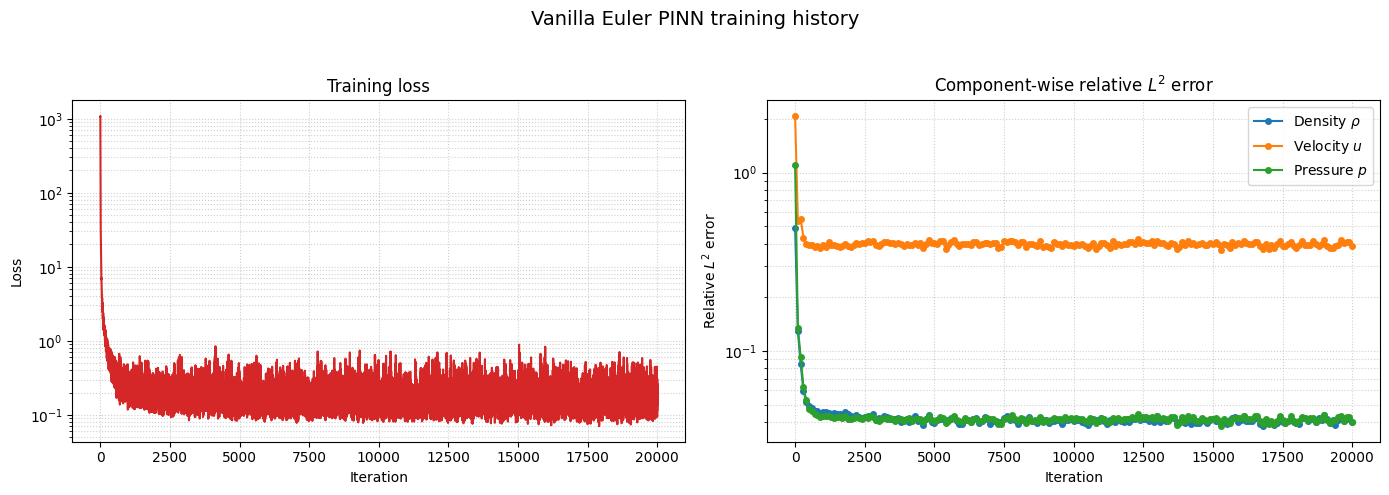

Plotting test grid: nt=129, nx=257
Evaluation errors:
  rho: MSE=7.361554e-04, RL2=3.976690e-02
  u  : MSE=2.851539e-02, RL2=3.894861e-01
  p  : MSE=7.098776e-04, RL2=3.991725e-02


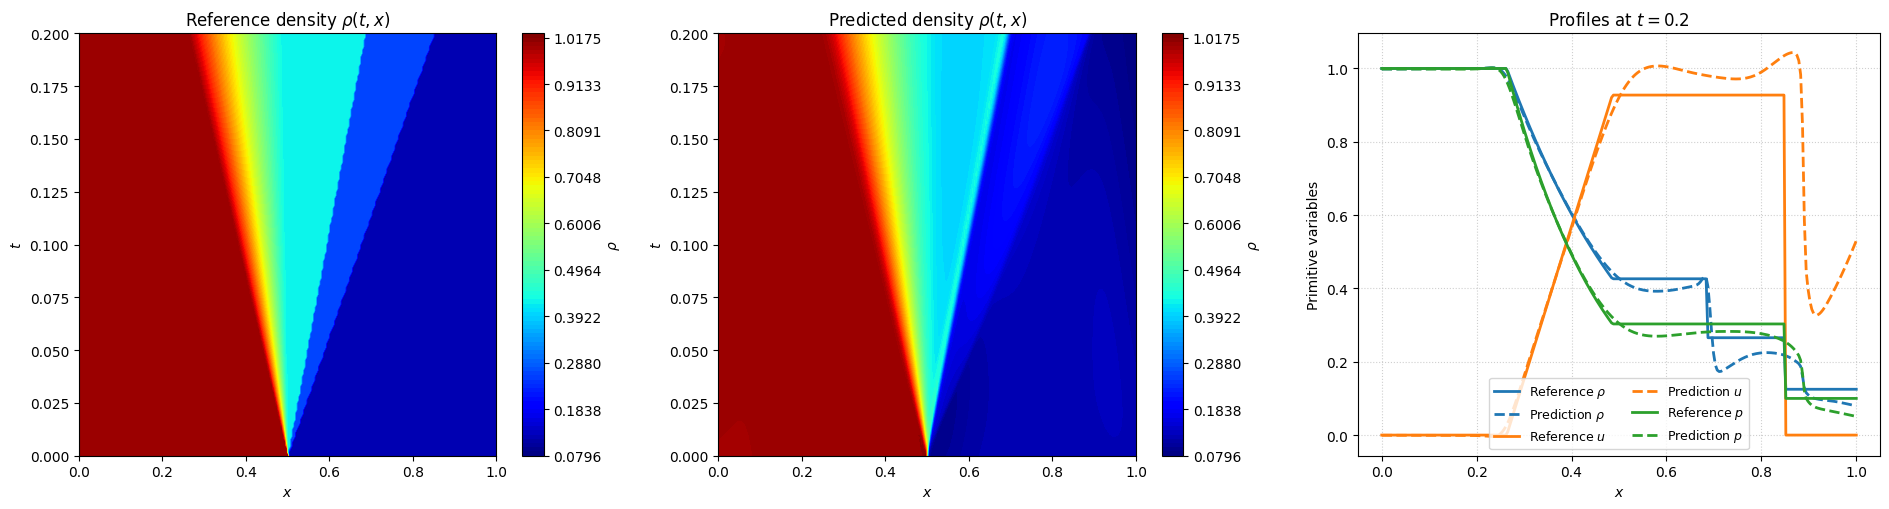

(array([0.00073616, 0.02851539, 0.00070988], dtype=float32),
 array([0.0397669 , 0.3894861 , 0.03991725], dtype=float32))

In [4]:
pde_params, key_train, history = train_pinn(
    pde_params=pde_params,
    pde_optimizer=pde_optimizer,
    pde_loss_grad_fn=pde_loss_grad_fn,
    pde_minibatch_fn=pde_minibatch_fn,
    eval_fn=eval_fn,
    test_inputs=test_inputs,
    test_labels=test_labels,
    key=key_train,
    nu=nu,
    max_iters=20000,
    pts_pde=10000,
    pts_ics=1000,
    max_runtime=10000.0,
    eval_every=100,
)

plot_training_history(
    history,
    metric="rl2",
    title="Vanilla Euler PINN training history",
)
plot_evaluation(
    params=pde_params,
    model=pde_net,
    t_test=t_test,
    x_test=x_test,
    labels_test=test_labels,
)

In [5]:
save_training_results(
    pde_params=pde_params,
    history=history,
    checkpoint_path=save_path,
    metadata={
        "seed": seed,
        "nu": nu,
        "max_iters": 20000,
        "pts_pde": 10000,
        "pts_ics": 1000,
        "eval_every": 100,
        "spatial_stride": sss,
    },
)

Training checkpoint saved to: /home/DG21210022/Amon/tal/shocktube/pinn_sod03.msgpack
Training history saved to: /home/DG21210022/Amon/tal/shocktube/pinn_sod03_history.npz
